# Analiza wyników — rozdział 3

In [4]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = Path('../results')
AGG_DIR = RESULTS_DIR / 'aggregation'
FIG_DIR = AGG_DIR / 'notebook_figs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['CICIDS', 'UNSW_NB15']
DATASET_LABELS = {'CICIDS': 'CICIDS 2017', 'UNSW_NB15': 'UNSW-NB15'}
COLORS = list(plt.cm.Set2.colors)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':'black','axes.grid':False,'font.size':10,'savefig.dpi':300,'legend.frameon':False})

df = pd.read_csv(AGG_DIR / 'all_results_flat.csv')
df_std = df[df['threshold_variant'].eq('standard')].copy()

def no_perturbation_mask(frame):
    mask = pd.Series(True, index=frame.index)
    for col in ['hyperparameters.feature_dropout', 'hyperparameters.imbalance_factor_test', 'hyperparameters.noise']:
        if col in frame.columns:
            mask &= frame[col].isna() | frame[col].eq(0)
    return mask

df_std_clean = df_std[no_perturbation_mask(df_std)].copy()

def norm(value):
    return re.sub(r'[^a-z0-9]+', '', str(value).lower())

def select(frame, dataset=None, model=None, fusion=None):
    out = frame.copy()
    if dataset is not None:
        out = out[out['dataset_name'].eq(dataset)]
    if model is not None:
        out = out[out['model_type'].map(norm).eq(norm(model))]
    if fusion is not None:
        if 'fusion_strategy' not in out.columns:
            return out.iloc[0:0]
        out = out[out['fusion_strategy'].fillna('').map(norm).eq(norm(fusion))]
    return out

def agg(frame, mask, metrics=('AUC_ROC','AUC_PR','Precision','Recall','F1','runtime_train','runtime_inference','ConfusionMatrix_TP','ConfusionMatrix_FP','ConfusionMatrix_TN','ConfusionMatrix_FN')):
    sub = frame.loc[mask]
    out = {'n': len(sub)}
    for metric in metrics:
        if metric in sub.columns:
            out[f'{metric}_mean'] = sub[metric].mean()
            out[f'{metric}_std'] = sub[metric].std()
    return out

def stats_for(frame):
    return {metric: (frame[metric].mean(), frame[metric].std()) if metric in frame.columns else (np.nan, np.nan) for metric in ['AUC_ROC','AUC_PR','Precision','Recall','F1','runtime_train','runtime_inference','ConfusionMatrix_FP','ConfusionMatrix_FN']}

def pm(mean, std, nd=3):
    if pd.isna(mean): return '--'
    if pd.isna(std): return f'{mean:.{nd}f}'
    return f'{mean:.{nd}f} ± {std:.{nd}f}'

def savefig(fig, name):
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Zapisano: {pdf_path.name} oraz {png_path.name}")


def to_latex_math(cell):
    s = str(cell)
    if s.strip() in ("--", "nan", ""):
        return "--"
    s = re.sub(r"(\d+)\.(\d+)", lambda m: m.group(1) + "{,}" + m.group(2), s)
    s = s.replace("±", "\\pm")
    return f"${s}$"


def export_table(rows, name, caption=None, label=None):
    table = pd.DataFrame(rows)
    display(table)
    table.to_csv(FIG_DIR / f"{name}.csv", index=False)

    cols = list(table.columns)
    id_cols = [c for c in cols if c in ("Zbiór", "Model", "Wariant")]
    metric_cols = [c for c in cols if c not in id_cols]
    align = "l" * len(id_cols) + "c" * len(metric_cols)

    cap = caption or name.replace("_", " ").replace("-", " ").capitalize()
    lab = label or f"tab:{name}"

    lines = [
        r"\begin{table}[H]", r"\centering", rf"\caption{{{cap}}}", rf"\label{{{lab}}}",
        r"\resizebox{\textwidth}{!}{%", rf"\begin{{tabular}}{{{align}}}", r"\hline",
        " & ".join(cols) + r" \\", r"\hline",
    ]

    group_col = "Zbiór" if "Zbiór" in cols else None
    prev_group = None
    for _, row in table.iterrows():
        if group_col and prev_group is not None and row[group_col] != prev_group:
            lines.append(r"\hline")
        cells = [str(row[c]) if c in id_cols else to_latex_math(row[c]) for c in cols]
        lines.append(" & ".join(cells) + r" \\")
        if group_col:
            prev_group = row[group_col]

    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    tex = "\n".join(lines)
    (FIG_DIR / f"{name}.tex").write_text(tex, encoding="utf-8")
    print(tex)
    return table


def bar_by_dataset(specs, metric, stem, ylabel, title, source=df_std_clean):
    fig, axes = plt.subplots(2, 1, figsize=(8, 7.5))
    
    for ax, ds in zip(axes, DATASETS):
        means, stds, labels = [], [], []
        for model, fusion, label in specs:
            sub = select(source, ds, model, fusion)
            means.append(sub[metric].mean() if metric in sub and not sub.empty else np.nan)
            stds.append(sub[metric].std() if metric in sub and not sub.empty else np.nan)
            labels.append(label)
            
        x = np.arange(len(labels))
        
        rects = ax.bar(
            x, 
            means, 
            yerr=stds, 
            capsize=5, 
            color=COLORS[:len(labels)], 
            ecolor="#404040", 
            alpha=0.9,
            error_kw={"elinewidth": 1.2, "capthick": 1.2}
        )
        
        for rect, mean, std in zip(rects, means, stds):
            if pd.notna(mean):
                offset = (std if pd.notna(std) else 0) + 0.02
                ax.text(
                    rect.get_x() + rect.get_width() / 2.0, 
                    mean + offset, 
                    f"{mean:.3f}", 
                    ha="center", 
                    va="bottom", 
                    fontsize=9
                )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10, labelpad=8)
        ax.set_title(DATASET_LABELS[ds], fontsize=11, pad=10)
        
        max_val = max([m + (s if pd.notna(s) else 0) for m, s in zip(means, stds) if pd.notna(m)], default=1)
        ax.set_ylim(0, max_val * 1.15)
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)
        
        ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)

    fig.suptitle(title, fontsize=12, y=0.99)
    fig.tight_layout(h_pad=3.0)
    savefig(fig, stem)
    plt.show()


In [5]:
## 1. Modele pojedyncze -- tabela
SOLO = [('IsolationForest', None, 'Isolation Forest'), ('LOF', None, 'LOF'),
        ('OneClassSVM', None, 'One-Class SVM'), ('LUNAR', None, 'LUNAR')]

rows = []
for ds in DATASETS:
    for model, fusion, label in SOLO:
        sub = select(df_std_clean, ds, model, fusion)
        values = stats_for(sub)
        rows.append({'Zbiór': DATASET_LABELS[ds], 'Model': label,
                      **{k: pm(*values[k]) for k in ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F1']}})

export_table(rows, 'tab_solo_final',
             caption="Wyniki modeli pojedynczych przy progu standardowym; średnia $\\pm$ odchylenie standardowe.",
             label="tab:solo_final")

,Zbiór,Model,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Isolation Forest,0.819 ± 0.009,0.608 ± 0.010,0.712 ± 0.200,0.501 ± 0.168,0.551 ± 0.016
1,CICIDS 2017,LOF,0.848 ± 0.008,0.543 ± 0.039,0.583 ± 0.005,0.766 ± 0.069,0.662 ± 0.026
2,CICIDS 2017,One-Class SVM,0.768 ± 0.001,0.623 ± 0.000,0.243 ± 0.000,1.000 ± 0.000,0.391 ± 0.000
3,CICIDS 2017,LUNAR,0.869 ± 0.004,0.743 ± 0.013,0.670 ± 0.020,0.687 ± 0.001,0.678 ± 0.010
4,UNSW-NB15,Isolation Forest,0.845 ± 0.001,0.885 ± 0.004,0.781 ± 0.005,0.814 ± 0.003,0.797 ± 0.004
5,UNSW-NB15,LOF,0.889 ± 0.004,0.920 ± 0.003,0.849 ± 0.010,0.805 ± 0.006,0.826 ± 0.001
6,UNSW-NB15,One-Class SVM,0.818 ± 0.002,0.850 ± 0.003,0.810 ± 0.019,0.762 ± 0.015,0.785 ± 0.001
7,UNSW-NB15,LUNAR,0.889 ± 0.005,0.930 ± 0.002,0.896 ± 0.006,0.790 ± 0.002,0.839 ± 0.002


\begin{table}[H]
\centering
\caption{Wyniki modeli pojedynczych przy progu standardowym; średnia $\pm$ odchylenie standardowe.}
\label{tab:solo_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Zbiór & Model & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
CICIDS 2017 & Isolation Forest & $0{,}819 \pm 0{,}009$ & $0{,}608 \pm 0{,}010$ & $0{,}712 \pm 0{,}200$ & $0{,}501 \pm 0{,}168$ & $0{,}551 \pm 0{,}016$ \\
CICIDS 2017 & LOF & $0{,}848 \pm 0{,}008$ & $0{,}543 \pm 0{,}039$ & $0{,}583 \pm 0{,}005$ & $0{,}766 \pm 0{,}069$ & $0{,}662 \pm 0{,}026$ \\
CICIDS 2017 & One-Class SVM & $0{,}768 \pm 0{,}001$ & $0{,}623 \pm 0{,}000$ & $0{,}243 \pm 0{,}000$ & $1{,}000 \pm 0{,}000$ & $0{,}391 \pm 0{,}000$ \\
CICIDS 2017 & LUNAR & $0{,}869 \pm 0{,}004$ & $0{,}743 \pm 0{,}013$ & $0{,}670 \pm 0{,}020$ & $0{,}687 \pm 0{,}001$ & $0{,}678 \pm 0{,}010$ \\
\hline
UNSW-NB15 & Isolation Forest & $0{,}845 \pm 0{,}001$ & $0{,}885 \pm 0{,}004$ & $0{,}781 \pm 0{,}005$ & $0{,}814 \pm 0{,}003$

,Zbiór,Model,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Isolation Forest,0.819 ± 0.009,0.608 ± 0.010,0.712 ± 0.200,0.501 ± 0.168,0.551 ± 0.016
1,CICIDS 2017,LOF,0.848 ± 0.008,0.543 ± 0.039,0.583 ± 0.005,0.766 ± 0.069,0.662 ± 0.026
2,CICIDS 2017,One-Class SVM,0.768 ± 0.001,0.623 ± 0.000,0.243 ± 0.000,1.000 ± 0.000,0.391 ± 0.000
3,CICIDS 2017,LUNAR,0.869 ± 0.004,0.743 ± 0.013,0.670 ± 0.020,0.687 ± 0.001,0.678 ± 0.010
4,UNSW-NB15,Isolation Forest,0.845 ± 0.001,0.885 ± 0.004,0.781 ± 0.005,0.814 ± 0.003,0.797 ± 0.004
5,UNSW-NB15,LOF,0.889 ± 0.004,0.920 ± 0.003,0.849 ± 0.010,0.805 ± 0.006,0.826 ± 0.001
6,UNSW-NB15,One-Class SVM,0.818 ± 0.002,0.850 ± 0.003,0.810 ± 0.019,0.762 ± 0.015,0.785 ± 0.001
7,UNSW-NB15,LUNAR,0.889 ± 0.005,0.930 ± 0.002,0.896 ± 0.006,0.790 ± 0.002,0.839 ± 0.002


Zapisano: figsolo-prauc-final.pdf oraz figsolo-prauc-final.png


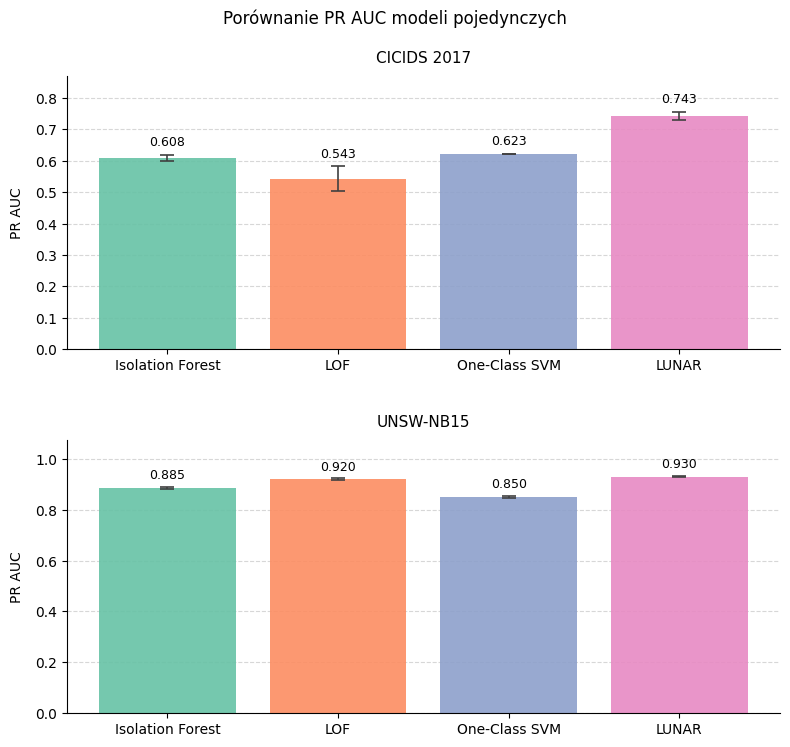

In [6]:
## 1. Modele pojedyncze -- wykres PR AUC
bar_by_dataset(SOLO, 'AUC_PR', 'figsolo-prauc-final', 'PR AUC', 'Porównanie PR AUC modeli pojedynczych')

Zapisano: figsolo-fpfn-final.pdf oraz figsolo-fpfn-final.png


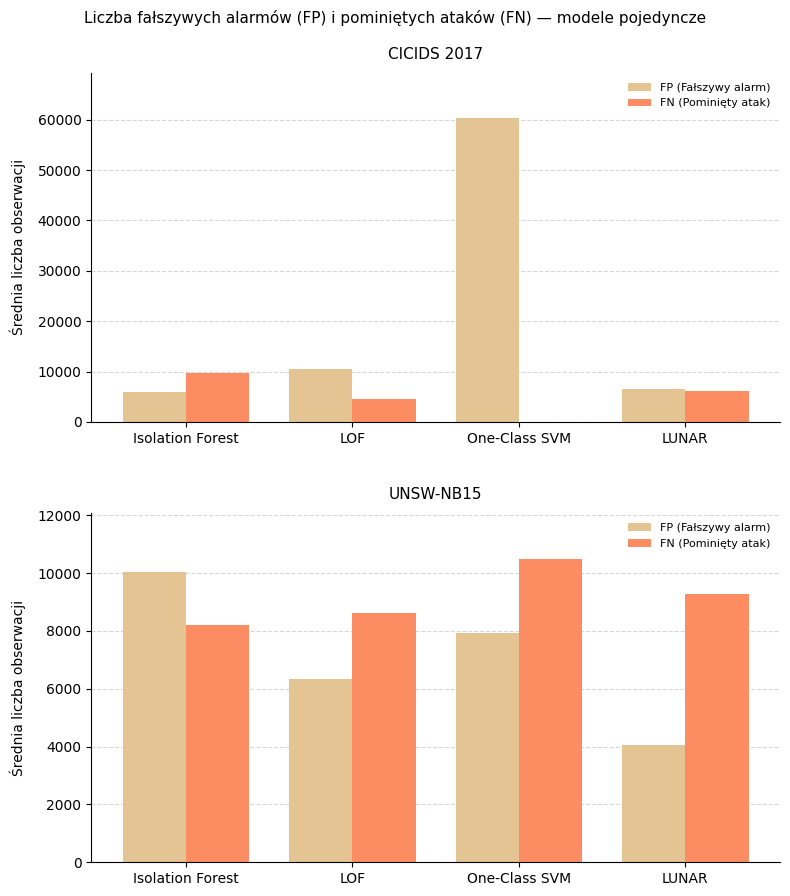

In [7]:
# figsolo-fpfn-final (fig:figsolo-fpfn-final)

fig, axes = plt.subplots(2, 1, figsize=(8, 9))
width = 0.38
x = np.arange(len(SOLO))
labels = [s[2] for s in SOLO]

for ax, ds in zip(axes, DATASETS):
    fps, fns = [], []
    for model, fusion, _ in SOLO:
        sub = select(df_std_clean, ds, model, fusion)
        fps.append(sub['ConfusionMatrix_FP'].mean() if 'ConfusionMatrix_FP' in sub and not sub.empty else 0)
        fns.append(sub['ConfusionMatrix_FN'].mean() if 'ConfusionMatrix_FN' in sub and not sub.empty else 0)
        
    rects1 = ax.bar(x - width/2, fps, width, label='FP (Fałszywy alarm)', color=COLORS[6])
    rects2 = ax.bar(x + width/2, fns, width, label='FN (Pominięty atak)', color=COLORS[1])
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_title(DATASET_LABELS[ds], fontsize=11, pad=10)
    ax.set_ylabel('Średnia liczba obserwacji', fontsize=10, labelpad=8)
    
    max_val = max(max(fps, default=0), max(fns, default=0))
    ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)
    
    # Stylizacja osi i siatki
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=8)

fig.suptitle('Liczba fałszywych alarmów (FP) i pominiętych ataków (FN) — modele pojedyncze', 
             fontsize=11, y=0.99)

fig.tight_layout(h_pad=3.0)
savefig(fig, 'figsolo-fpfn-final')
plt.show()

In [8]:
## 2–4. Zespoły LUNAR, klasyczne oraz wkład LUNAR -- konfiguracja
SELF = [('LUNAR', None, 'LUNAR pojedynczy'), ('LUNAR_Self_Ensemble', 'bagging', 'Bagging'),
        ('LUNAR_Self_Ensemble', 'boosting', 'Boosting'), ('LUNAR_Self_Ensemble', 'stacking', 'Stacking'),
        ('LUNAR_Self_Ensemble', 'voting', 'Voting')]
CLASSICAL = [('IsolationForest', None, 'Isolation Forest'), ('LOF', None, 'LOF'),
             ('OneClassSVM', None, 'One-Class SVM'), ('Ensemble_without_LUNAR', 'rank_mean', 'Zespół klasyczny')]
CONTRIBUTION = [('LUNAR', None, 'LUNAR'), ('Ensemble_without_LUNAR', 'rank_mean', 'Zespół klasyczny'),
                ('Ensemble_with_LUNAR', 'rank_mean', 'Zespół z LUNAR')]


def table_for_specs(specs, name, include_runtime=False, caption=None, label=None):
    rows = []
    metrics = ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F1'] + \
              (['runtime_train', 'runtime_inference'] if include_runtime else [])
    for ds in DATASETS:
        for model, fusion, label_v in specs:
            values = stats_for(select(df_std_clean, ds, model, fusion))
            rows.append({'Zbiór': DATASET_LABELS[ds], 'Wariant': label_v,
                         **{m: pm(*values[m], nd=1 if 'runtime' in m else 3) for m in metrics}})
    return export_table(rows, name, caption=caption, label=label)

Zapisano: figlunar-self-ensemble-runtime-final.pdf oraz figlunar-self-ensemble-runtime-final.png


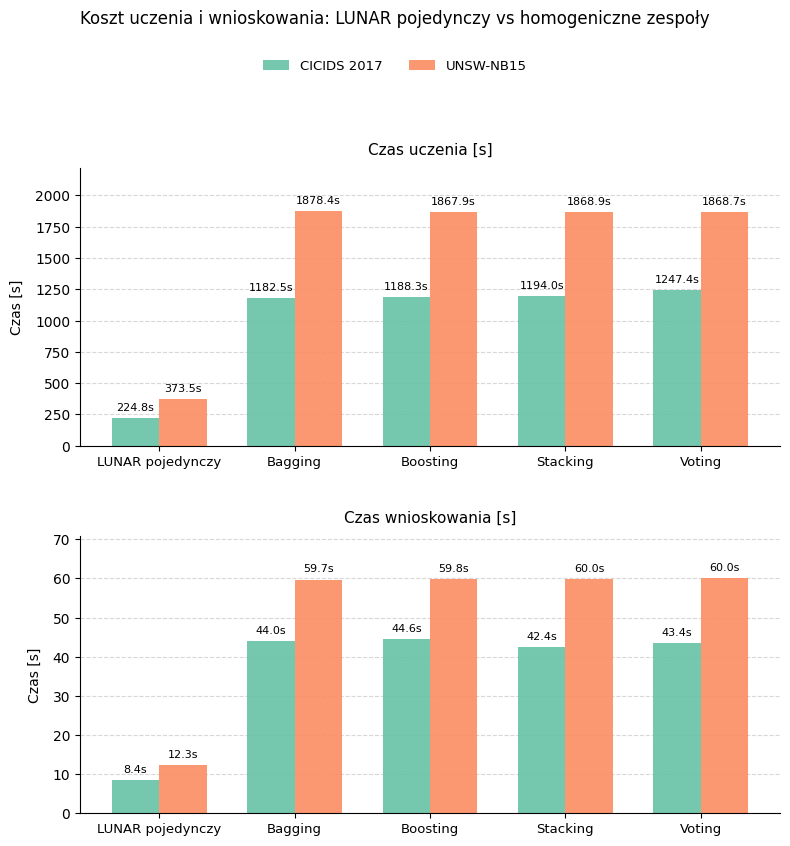

In [9]:
# ## 2-4. Zespoły LUNAR -- wykres kosztu (czas uczenia i wnioskowania)

fig, axes = plt.subplots(2, 1, figsize=(8, 8.5))
labels = [s[2] for s in SELF]
width = 0.35
x = np.arange(len(labels))

metrics = ['runtime_train', 'runtime_inference']
titles = ['Czas uczenia [s]', 'Czas wnioskowania [s]']

for ax, metric, title in zip(axes, metrics, titles):
    for j, ds in enumerate(DATASETS):
        vals = []
        for model, fusion, _ in SELF:
            sub = select(df_std_clean, ds, model, fusion)
            vals.append(sub[metric].mean() if metric in sub and not sub.empty else np.nan)
        
        rects = ax.bar(
            x + (j - 0.5) * width, 
            vals, 
            width, 
            label=DATASET_LABELS[ds], 
            color=COLORS[j], 
            alpha=0.9
        )
        
        for rect, val in zip(rects, vals):
            if pd.notna(val):
                ax.annotate(
                    f"{val:.1f}s",
                    xy=(rect.get_x() + rect.get_width() / 2.0, rect.get_height()),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8
                )

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=9.5)
    ax.set_ylabel("Czas [s]", fontsize=10, labelpad=8)
    
    all_vals = [
        select(df_std_clean, ds, m, f)[metric].mean() 
        for ds in DATASETS for m, f, _ in SELF 
        if not select(df_std_clean, ds, m, f).empty
    ]
    max_val = max(all_vals) if all_vals else 1
    ax.set_ylim(0, max_val * 1.18)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle('Koszt uczenia i wnioskowania: LUNAR pojedynczy vs homogeniczne zespoły', 
             fontsize=12, y=0.99)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, 
    loc="upper center", 
    ncol=2, 
    frameon=True, 
    facecolor="white", 
    edgecolor="none",
    bbox_to_anchor=(0.5, 0.945),
    fontsize=9.5
)

fig.tight_layout(rect=[0, 0, 1, 0.89], h_pad=3.0)
savefig(fig, 'figlunar-self-ensemble-runtime-final')
plt.show()

In [10]:
table_for_specs(SELF, 'tab_lunar_self_ensemble_final', include_runtime=True,
                 caption="Porównanie pojedynczego LUNAR i homogenicznych zespołów LUNAR przy progu standardowym.",
                 label="tab:lunar_self_ensemble_final")

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR pojedynczy,0.869 ± 0.004,0.743 ± 0.013,0.670 ± 0.020,0.687 ± 0.001,0.678 ± 0.010,224.8 ± 80.4,8.4 ± 1.3
1,CICIDS 2017,Bagging,0.865 ± 0.002,0.735 ± 0.001,0.649 ± 0.010,0.690 ± 0.001,0.668 ± 0.005,1182.5 ± 397.0,44.0 ± 9.0
2,CICIDS 2017,Boosting,0.867 ± 0.000,0.736 ± 0.002,0.650 ± 0.007,0.688 ± 0.001,0.669 ± 0.003,1188.3 ± 409.4,44.6 ± 10.1
3,CICIDS 2017,Stacking,0.782 ± 0.145,0.684 ± 0.087,0.727 ± 0.123,0.613 ± 0.132,0.649 ± 0.041,1194.0 ± 375.2,42.4 ± 5.8
4,CICIDS 2017,Voting,0.794 ± 0.004,0.551 ± 0.006,0.683 ± 0.004,0.682 ± 0.001,0.682 ± 0.002,1247.4 ± 368.0,43.4 ± 5.4
5,UNSW-NB15,LUNAR pojedynczy,0.889 ± 0.005,0.930 ± 0.002,0.896 ± 0.006,0.790 ± 0.002,0.839 ± 0.002,373.5 ± 61.9,12.3 ± 1.1
6,UNSW-NB15,Bagging,0.888 ± 0.005,0.930 ± 0.002,0.906 ± 0.016,0.783 ± 0.007,0.840 ± 0.006,1878.4 ± 308.0,59.7 ± 4.5
7,UNSW-NB15,Boosting,0.888 ± 0.004,0.928 ± 0.003,0.909 ± 0.016,0.781 ± 0.006,0.840 ± 0.006,1867.9 ± 295.8,59.8 ± 4.7
8,UNSW-NB15,Stacking,0.892 ± 0.003,0.932 ± 0.002,0.906 ± 0.014,0.782 ± 0.008,0.839 ± 0.006,1868.9 ± 299.7,60.0 ± 5.1
9,UNSW-NB15,Voting,0.849 ± 0.005,0.843 ± 0.009,0.895 ± 0.006,0.788 ± 0.007,0.838 ± 0.003,1868.7 ± 298.1,60.0 ± 5.1


\begin{table}[H]
\centering
\caption{Porównanie pojedynczego LUNAR i homogenicznych zespołów LUNAR przy progu standardowym.}
\label{tab:lunar_self_ensemble_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Zbiór & Wariant & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
CICIDS 2017 & LUNAR pojedynczy & $0{,}869 \pm 0{,}004$ & $0{,}743 \pm 0{,}013$ & $0{,}670 \pm 0{,}020$ & $0{,}687 \pm 0{,}001$ & $0{,}678 \pm 0{,}010$ & $224{,}8 \pm 80{,}4$ & $8{,}4 \pm 1{,}3$ \\
CICIDS 2017 & Bagging & $0{,}865 \pm 0{,}002$ & $0{,}735 \pm 0{,}001$ & $0{,}649 \pm 0{,}010$ & $0{,}690 \pm 0{,}001$ & $0{,}668 \pm 0{,}005$ & $1182{,}5 \pm 397{,}0$ & $44{,}0 \pm 9{,}0$ \\
CICIDS 2017 & Boosting & $0{,}867 \pm 0{,}000$ & $0{,}736 \pm 0{,}002$ & $0{,}650 \pm 0{,}007$ & $0{,}688 \pm 0{,}001$ & $0{,}669 \pm 0{,}003$ & $1188{,}3 \pm 409{,}4$ & $44{,}6 \pm 10{,}1$ \\
CICIDS 2017 & Stacking & $0{,}782 \pm 0{,}145$ & $0{,}684 \pm 0{,}087$ & $0{,}727 \pm 0

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR pojedynczy,0.869 ± 0.004,0.743 ± 0.013,0.670 ± 0.020,0.687 ± 0.001,0.678 ± 0.010,224.8 ± 80.4,8.4 ± 1.3
1,CICIDS 2017,Bagging,0.865 ± 0.002,0.735 ± 0.001,0.649 ± 0.010,0.690 ± 0.001,0.668 ± 0.005,1182.5 ± 397.0,44.0 ± 9.0
2,CICIDS 2017,Boosting,0.867 ± 0.000,0.736 ± 0.002,0.650 ± 0.007,0.688 ± 0.001,0.669 ± 0.003,1188.3 ± 409.4,44.6 ± 10.1
3,CICIDS 2017,Stacking,0.782 ± 0.145,0.684 ± 0.087,0.727 ± 0.123,0.613 ± 0.132,0.649 ± 0.041,1194.0 ± 375.2,42.4 ± 5.8
4,CICIDS 2017,Voting,0.794 ± 0.004,0.551 ± 0.006,0.683 ± 0.004,0.682 ± 0.001,0.682 ± 0.002,1247.4 ± 368.0,43.4 ± 5.4
5,UNSW-NB15,LUNAR pojedynczy,0.889 ± 0.005,0.930 ± 0.002,0.896 ± 0.006,0.790 ± 0.002,0.839 ± 0.002,373.5 ± 61.9,12.3 ± 1.1
6,UNSW-NB15,Bagging,0.888 ± 0.005,0.930 ± 0.002,0.906 ± 0.016,0.783 ± 0.007,0.840 ± 0.006,1878.4 ± 308.0,59.7 ± 4.5
7,UNSW-NB15,Boosting,0.888 ± 0.004,0.928 ± 0.003,0.909 ± 0.016,0.781 ± 0.006,0.840 ± 0.006,1867.9 ± 295.8,59.8 ± 4.7
8,UNSW-NB15,Stacking,0.892 ± 0.003,0.932 ± 0.002,0.906 ± 0.014,0.782 ± 0.008,0.839 ± 0.006,1868.9 ± 299.7,60.0 ± 5.1
9,UNSW-NB15,Voting,0.849 ± 0.005,0.843 ± 0.009,0.895 ± 0.006,0.788 ± 0.007,0.838 ± 0.003,1868.7 ± 298.1,60.0 ± 5.1


Zapisano: figlunar-self-ensemble-prauc-final.pdf oraz figlunar-self-ensemble-prauc-final.png


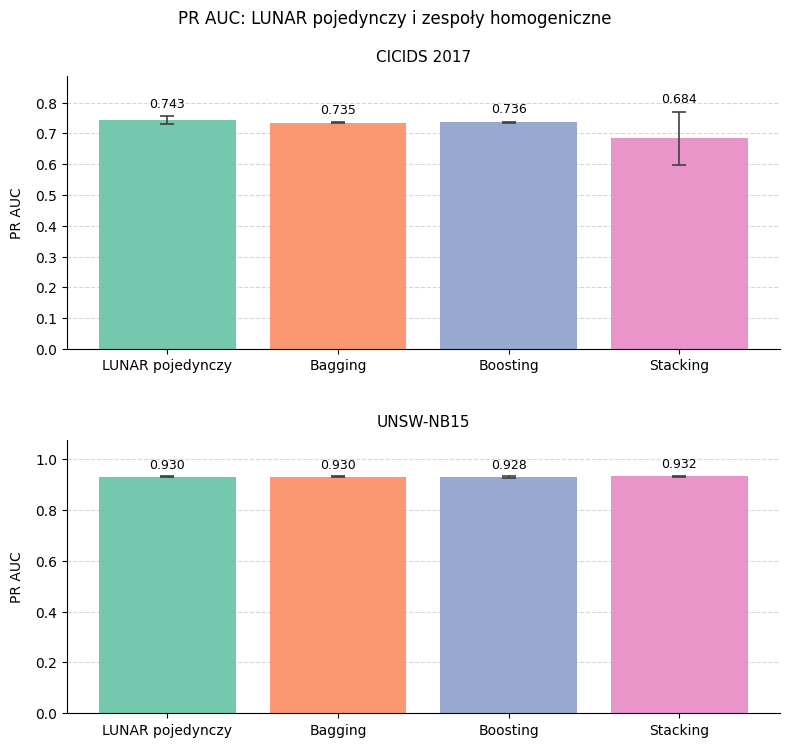

In [11]:
bar_by_dataset(SELF[:-1], 'AUC_PR', 'figlunar-self-ensemble-prauc-final', 'PR AUC',
               'PR AUC: LUNAR pojedynczy i zespoły homogeniczne')

Zapisano: figclassical-ensemble-prauc-final.pdf oraz figclassical-ensemble-prauc-final.png


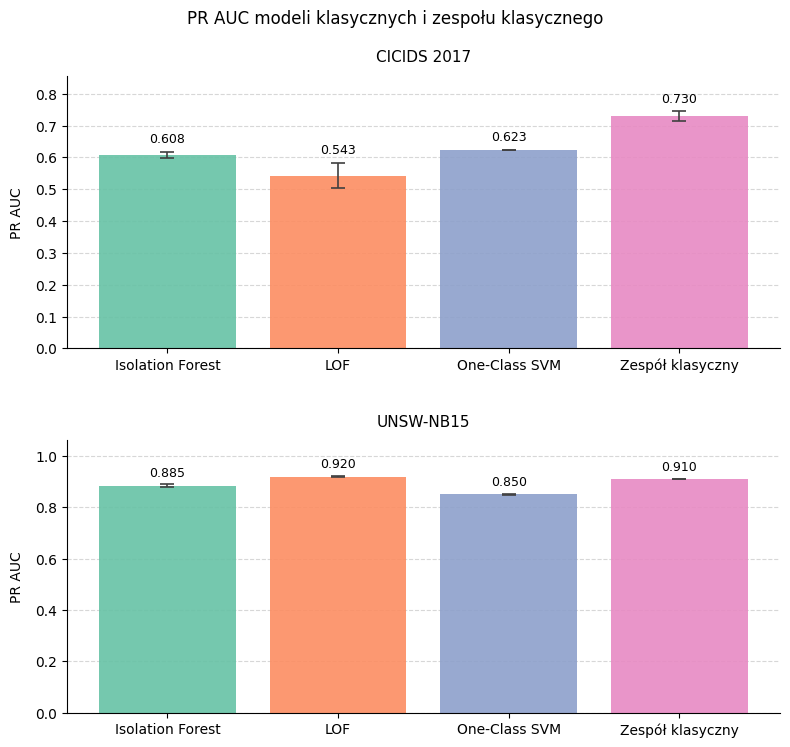

In [12]:
bar_by_dataset(CLASSICAL, 'AUC_PR', 'figclassical-ensemble-prauc-final', 'PR AUC',
               'PR AUC modeli klasycznych i zespołu klasycznego')

Zapisano: figclassical-ensemble-prauc-final.pdf oraz figclassical-ensemble-prauc-final.png


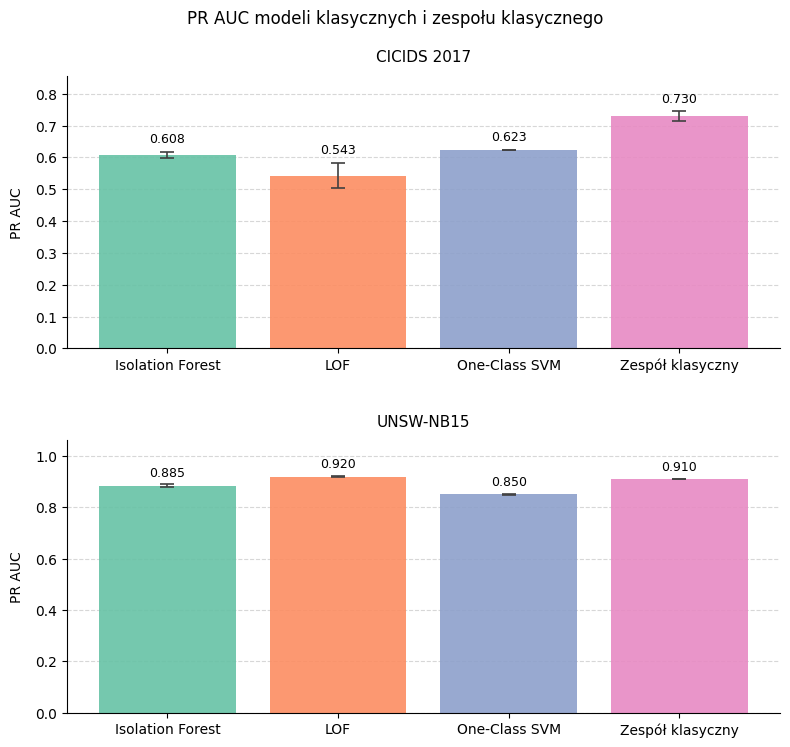

In [13]:
bar_by_dataset(CLASSICAL, 'AUC_PR', 'figclassical-ensemble-prauc-final', 'PR AUC',
               'PR AUC modeli klasycznych i zespołu klasycznego')

In [14]:
table_for_specs(CONTRIBUTION, 'tab_lunar_contribution_final', include_runtime=True,
                 caption="Wkład LUNAR w zespole: porównanie LUNAR, zespołu klasycznego i zespołu z LUNAR.",
                 label="tab:lunar_contribution_final")

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR,0.869 ± 0.004,0.743 ± 0.013,0.670 ± 0.020,0.687 ± 0.001,0.678 ± 0.010,224.8 ± 80.4,8.4 ± 1.3
1,CICIDS 2017,Zespół klasyczny,0.882 ± 0.002,0.730 ± 0.015,0.710 ± 0.020,0.736 ± 0.024,0.722 ± 0.003,10.9 ± 5.2,18.7 ± 11.0
2,CICIDS 2017,Zespół z LUNAR,0.887 ± 0.002,0.747 ± 0.011,0.666 ± 0.020,0.745 ± 0.007,0.703 ± 0.008,244.4 ± 79.9,27.3 ± 11.8
3,UNSW-NB15,LUNAR,0.889 ± 0.005,0.930 ± 0.002,0.896 ± 0.006,0.790 ± 0.002,0.839 ± 0.002,373.5 ± 61.9,12.3 ± 1.1
4,UNSW-NB15,Zespół klasyczny,0.875 ± 0.001,0.910 ± 0.000,0.834 ± 0.008,0.781 ± 0.014,0.806 ± 0.004,109.8 ± 10.8,141.1 ± 9.9
5,UNSW-NB15,Zespół z LUNAR,0.892 ± 0.000,0.925 ± 0.001,0.803 ± 0.004,0.839 ± 0.006,0.820 ± 0.001,518.3 ± 155.1,167.2 ± 3.7


\begin{table}[H]
\centering
\caption{Wkład LUNAR w zespole: porównanie LUNAR, zespołu klasycznego i zespołu z LUNAR.}
\label{tab:lunar_contribution_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccccc}
\hline
Zbiór & Wariant & AUC_ROC & AUC_PR & Precision & Recall & F1 & runtime_train & runtime_inference \\
\hline
CICIDS 2017 & LUNAR & $0{,}869 \pm 0{,}004$ & $0{,}743 \pm 0{,}013$ & $0{,}670 \pm 0{,}020$ & $0{,}687 \pm 0{,}001$ & $0{,}678 \pm 0{,}010$ & $224{,}8 \pm 80{,}4$ & $8{,}4 \pm 1{,}3$ \\
CICIDS 2017 & Zespół klasyczny & $0{,}882 \pm 0{,}002$ & $0{,}730 \pm 0{,}015$ & $0{,}710 \pm 0{,}020$ & $0{,}736 \pm 0{,}024$ & $0{,}722 \pm 0{,}003$ & $10{,}9 \pm 5{,}2$ & $18{,}7 \pm 11{,}0$ \\
CICIDS 2017 & Zespół z LUNAR & $0{,}887 \pm 0{,}002$ & $0{,}747 \pm 0{,}011$ & $0{,}666 \pm 0{,}020$ & $0{,}745 \pm 0{,}007$ & $0{,}703 \pm 0{,}008$ & $244{,}4 \pm 79{,}9$ & $27{,}3 \pm 11{,}8$ \\
\hline
UNSW-NB15 & LUNAR & $0{,}889 \pm 0{,}005$ & $0{,}930 \pm 0{,}002$ & $0{,}896 \pm 0{,}006$

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1,runtime_train,runtime_inference
0,CICIDS 2017,LUNAR,0.869 ± 0.004,0.743 ± 0.013,0.670 ± 0.020,0.687 ± 0.001,0.678 ± 0.010,224.8 ± 80.4,8.4 ± 1.3
1,CICIDS 2017,Zespół klasyczny,0.882 ± 0.002,0.730 ± 0.015,0.710 ± 0.020,0.736 ± 0.024,0.722 ± 0.003,10.9 ± 5.2,18.7 ± 11.0
2,CICIDS 2017,Zespół z LUNAR,0.887 ± 0.002,0.747 ± 0.011,0.666 ± 0.020,0.745 ± 0.007,0.703 ± 0.008,244.4 ± 79.9,27.3 ± 11.8
3,UNSW-NB15,LUNAR,0.889 ± 0.005,0.930 ± 0.002,0.896 ± 0.006,0.790 ± 0.002,0.839 ± 0.002,373.5 ± 61.9,12.3 ± 1.1
4,UNSW-NB15,Zespół klasyczny,0.875 ± 0.001,0.910 ± 0.000,0.834 ± 0.008,0.781 ± 0.014,0.806 ± 0.004,109.8 ± 10.8,141.1 ± 9.9
5,UNSW-NB15,Zespół z LUNAR,0.892 ± 0.000,0.925 ± 0.001,0.803 ± 0.004,0.839 ± 0.006,0.820 ± 0.001,518.3 ± 155.1,167.2 ± 3.7


Zapisano: figlunar-contribution-prauc-final.pdf oraz figlunar-contribution-prauc-final.png


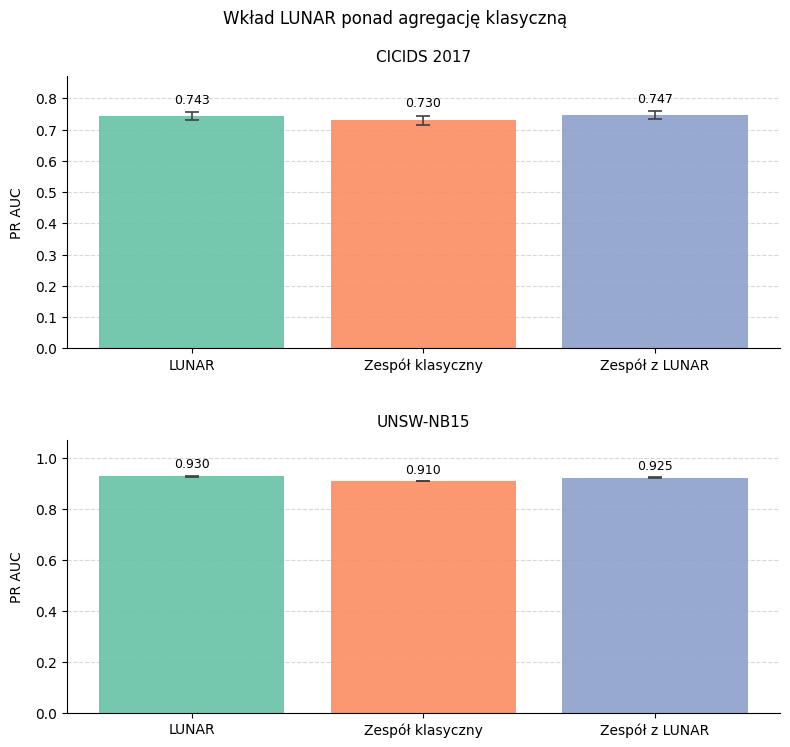

In [15]:
bar_by_dataset(CONTRIBUTION, 'AUC_PR', 'figlunar-contribution-prauc-final', 'PR AUC',
               'Wkład LUNAR ponad agregację klasyczną')

Zapisano: figoperational-fpfn-final.pdf oraz figoperational-fpfn-final.png


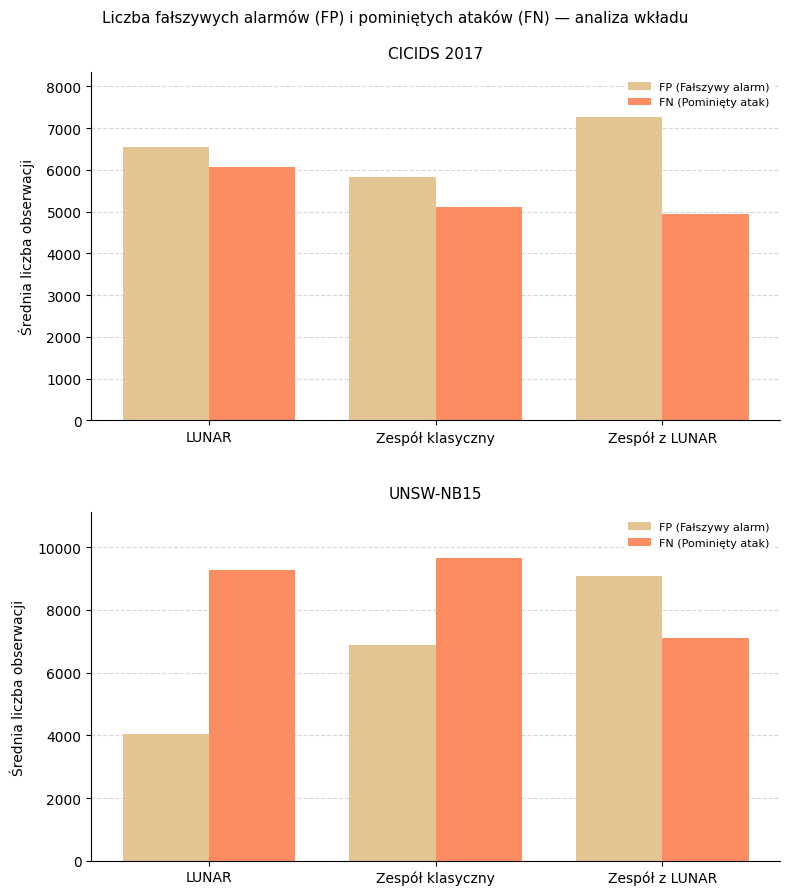

In [16]:
# figoperational-fpfn-final (fig:figoperational-fpfn-final)

fig, axes = plt.subplots(2, 1, figsize=(8, 9))
width = 0.38
x = np.arange(len(CONTRIBUTION))
labels = [s[2] for s in CONTRIBUTION]

for ax, ds in zip(axes, DATASETS):
    fp, fn = [], []
    for model, fusion, _ in CONTRIBUTION:
        sub = select(df_std_clean, ds, model, fusion)
        fp.append(sub['ConfusionMatrix_FP'].mean() if 'ConfusionMatrix_FP' in sub and not sub.empty else 0)
        fn.append(sub['ConfusionMatrix_FN'].mean() if 'ConfusionMatrix_FN' in sub and not sub.empty else 0)
        
    rects1 = ax.bar(x - width/2, fp, width, label='FP (Fałszywy alarm)', color=COLORS[6])
    rects2 = ax.bar(x + width/2, fn, width, label='FN (Pominięty atak)', color=COLORS[1])
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_title(DATASET_LABELS[ds], fontsize=11, pad=10)
    ax.set_ylabel('Średnia liczba obserwacji', fontsize=10, labelpad=8)
    
    max_val = max(max(fp, default=0), max(fn, default=0))
    ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)
    
    # Stylizacja osi i siatki
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=8)

fig.suptitle('Liczba fałszywych alarmów (FP) i pominiętych ataków (FN) — analiza wkładu', 
             fontsize=11, y=0.99)

fig.tight_layout(h_pad=3.0)
savefig(fig, "figoperational-fpfn-final")
plt.show()

In [17]:
## 5. Poziomy fuzji -- konfiguracja i tabela
FUSION = [('Fusion_Level_Comparison', 'feature_level', 'Fuzja cech'),
          ('Fusion_Level_Comparison', 'score_level', 'Fuzja wyników'),
          ('Fusion_Level_Comparison', 'decision_and', 'Decyzja AND'),
          ('Fusion_Level_Comparison', 'decision_or', 'Decyzja OR')]

table_for_specs(FUSION, 'tab_fusion_levels_final',
                caption="Porównanie poziomów fuzji LUNAR i LOF przy progu standardowym.",
                label="tab:fusion_levels_final")

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Fuzja cech,0.960 ± 0.000,0.882 ± 0.002,0.794 ± 0.001,0.842 ± 0.010,0.817 ± 0.005
1,CICIDS 2017,Fuzja wyników,0.894 ± 0.004,0.683 ± 0.016,0.696 ± 0.046,0.840 ± 0.029,0.760 ± 0.017
2,CICIDS 2017,Decyzja AND,--,--,--,--,--
3,CICIDS 2017,Decyzja OR,--,--,--,--,--
4,UNSW-NB15,Fuzja cech,0.950 ± 0.004,0.963 ± 0.002,0.811 ± 0.003,0.923 ± 0.018,0.863 ± 0.008
5,UNSW-NB15,Fuzja wyników,0.904 ± 0.004,0.933 ± 0.002,0.834 ± 0.073,0.809 ± 0.055,0.818 ± 0.004
6,UNSW-NB15,Decyzja AND,--,--,--,--,--
7,UNSW-NB15,Decyzja OR,--,--,--,--,--


\begin{table}[H]
\centering
\caption{Porównanie poziomów fuzji LUNAR i LOF przy progu standardowym.}
\label{tab:fusion_levels_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Zbiór & Wariant & AUC_ROC & AUC_PR & Precision & Recall & F1 \\
\hline
CICIDS 2017 & Fuzja cech & $0{,}960 \pm 0{,}000$ & $0{,}882 \pm 0{,}002$ & $0{,}794 \pm 0{,}001$ & $0{,}842 \pm 0{,}010$ & $0{,}817 \pm 0{,}005$ \\
CICIDS 2017 & Fuzja wyników & $0{,}894 \pm 0{,}004$ & $0{,}683 \pm 0{,}016$ & $0{,}696 \pm 0{,}046$ & $0{,}840 \pm 0{,}029$ & $0{,}760 \pm 0{,}017$ \\
CICIDS 2017 & Decyzja AND & -- & -- & -- & -- & -- \\
CICIDS 2017 & Decyzja OR & -- & -- & -- & -- & -- \\
\hline
UNSW-NB15 & Fuzja cech & $0{,}950 \pm 0{,}004$ & $0{,}963 \pm 0{,}002$ & $0{,}811 \pm 0{,}003$ & $0{,}923 \pm 0{,}018$ & $0{,}863 \pm 0{,}008$ \\
UNSW-NB15 & Fuzja wyników & $0{,}904 \pm 0{,}004$ & $0{,}933 \pm 0{,}002$ & $0{,}834 \pm 0{,}073$ & $0{,}809 \pm 0{,}055$ & $0{,}818 \pm 0{,}004$ \\
UNSW-NB15 & Decyzja AND & --

,Zbiór,Wariant,AUC_ROC,AUC_PR,Precision,Recall,F1
0,CICIDS 2017,Fuzja cech,0.960 ± 0.000,0.882 ± 0.002,0.794 ± 0.001,0.842 ± 0.010,0.817 ± 0.005
1,CICIDS 2017,Fuzja wyników,0.894 ± 0.004,0.683 ± 0.016,0.696 ± 0.046,0.840 ± 0.029,0.760 ± 0.017
2,CICIDS 2017,Decyzja AND,--,--,--,--,--
3,CICIDS 2017,Decyzja OR,--,--,--,--,--
4,UNSW-NB15,Fuzja cech,0.950 ± 0.004,0.963 ± 0.002,0.811 ± 0.003,0.923 ± 0.018,0.863 ± 0.008
5,UNSW-NB15,Fuzja wyników,0.904 ± 0.004,0.933 ± 0.002,0.834 ± 0.073,0.809 ± 0.055,0.818 ± 0.004
6,UNSW-NB15,Decyzja AND,--,--,--,--,--
7,UNSW-NB15,Decyzja OR,--,--,--,--,--


Zapisano: figfusion-levels-prauc-f1-final.pdf oraz figfusion-levels-prauc-f1-final.png


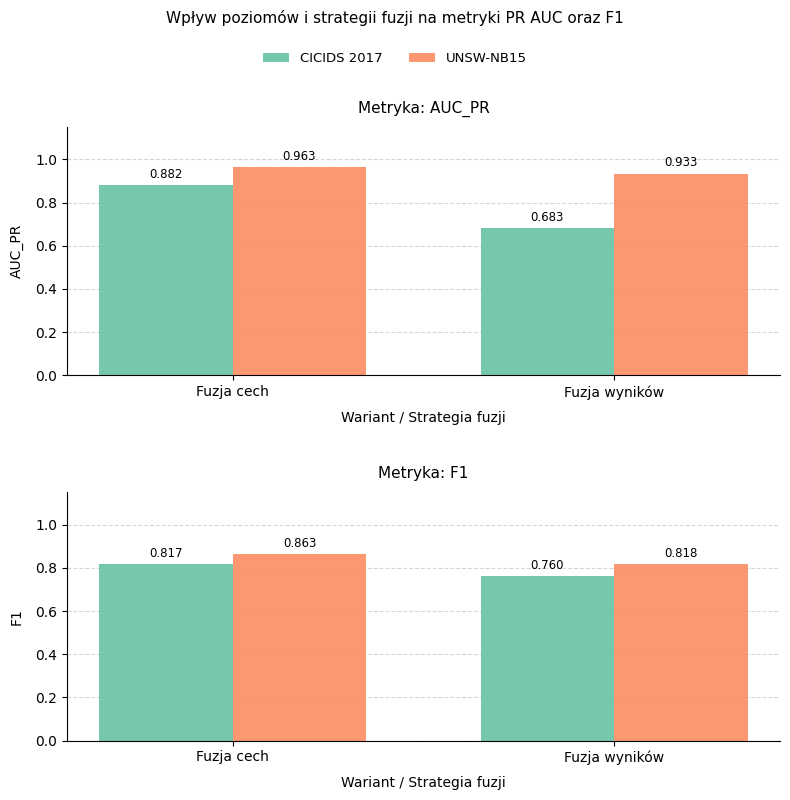

In [18]:
# figfusion-levels-prauc-f1-final (fig:figfusion-levels-prauc-f1-final)

fusion_filtered = [s for s in FUSION if "Decyzja" not in s[2]]

fig, axes = plt.subplots(2, 1, figsize=(8, 7.5))
width = 0.35
labels = [s[2] for s in fusion_filtered]
xpos = np.arange(len(labels))

for ax, metric in zip(axes, ['AUC_PR', 'F1']):
    for j, ds in enumerate(DATASETS):
        values = []
        for m, f, _ in fusion_filtered:
            sub = select(df_std_clean, ds, m, f)
            val = sub[metric].mean() if metric in sub and not sub.empty else np.nan
            values.append(val)
            
        rects = ax.bar(
            xpos + (j - 0.5) * width,
            values,
            width,
            label=DATASET_LABELS[ds],
            color=COLORS[j],
            alpha=0.9
        )
        
        for rect in rects:
            h = rect.get_height()
            if pd.notna(h) and h > 0:
                ax.annotate(
                    f"{h:.3f}",
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.5
                )

    ax.set_xticks(xpos)
    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_xlabel("Wariant / Strategia fuzji", fontsize=10, labelpad=8)
    ax.set_ylabel(metric, fontsize=10, labelpad=8)
    ax.set_title(f"Metryka: {metric}", fontsize=11, pad=10)
    
    ax.set_ylim(0, 1.15)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, 
    loc="upper center", 
    ncol=2, 
    frameon=True, 
    facecolor="white", 
    edgecolor="none",
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9.5
)

fig.suptitle("Wpływ poziomów i strategii fuzji na metryki PR AUC oraz F1", 
             fontsize=11, y=1.06)

fig.tight_layout(h_pad=3.0)
savefig(fig, "figfusion-levels-prauc-f1-final")
plt.show()

In [19]:
def get_curve(sub):
    if sub.empty or 'pr_curve_json' not in sub or not sub['pr_curve_json'].notna().any():
        return None, np.nan
    row = sub.loc[sub['AUC_PR'].idxmax()]
    try:
        return pd.DataFrame(json.loads(row['pr_curve_json'])), row['AUC_PR']
    except (ValueError, TypeError, KeyError):
        return None, np.nan

Zapisano: figfusion-pr-curves-final.pdf oraz figfusion-pr-curves-final.png


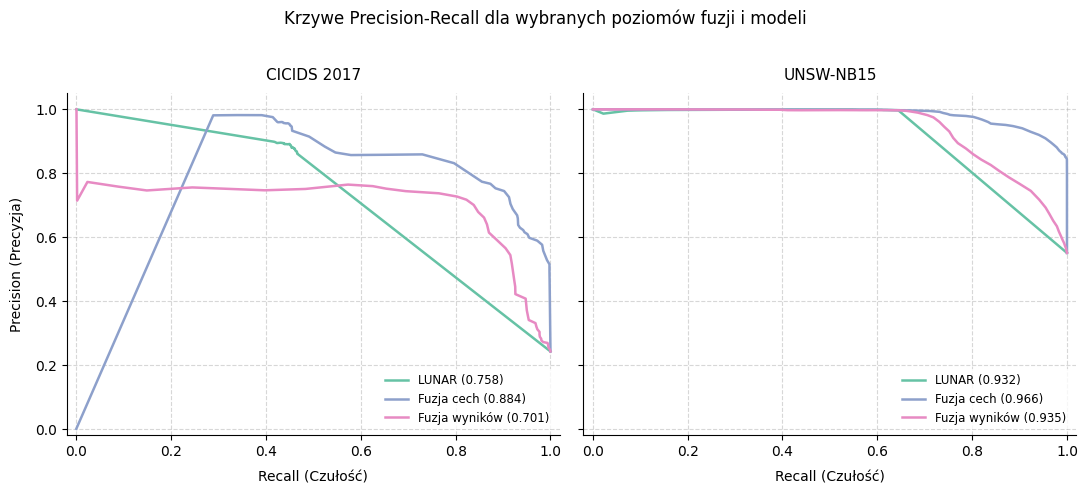

In [20]:
# figfusion-pr-curves-final (fig:figfusion-pr-curves-final)

PR_SPECS = [
    ('LUNAR', None, 'LUNAR'), 
    ('LOF', None, 'LOF'),
    ('Fusion_Level_Comparison', 'feature_level', 'Fuzja cech'),
    ('Fusion_Level_Comparison', 'score_level', 'Fuzja wyników')
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)

for ax, ds in zip(axes, DATASETS):
    for idx, (model, fusion, label) in enumerate(PR_SPECS):
        sub = select(df_std_clean, ds, model, fusion)
        curve, auc = get_curve(sub)
        
        if curve is not None and {'recall', 'precision'}.issubset(curve.columns):
            ax.plot(
                curve['recall'], 
                curve['precision'], 
                label=f'{label} ({auc:.3f})',
                color=COLORS[idx],
                linewidth=1.8
            )

    ax.set_title(DATASET_LABELS[ds], fontsize=11, pad=10)
    ax.set_xlabel('Recall (Czułość)', fontsize=10, labelpad=8)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    
    ax.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    
    ax.legend(
        loc='lower right', 
        frameon=True, 
        facecolor='white', 
        edgecolor='none', 
        fontsize=8.5
    )

axes[0].set_ylabel('Precision (Precyzja)', fontsize=10, labelpad=8)

fig.suptitle('Krzywe Precision-Recall dla wybranych poziomów fuzji i modeli', 
             fontsize=12, y=1.02)

fig.tight_layout()
savefig(fig, "figfusion-pr-curves-final")
plt.show()

In [21]:
## 6a. Liczba epok - konfiguracja i tabela
epochs = df_std[df_std['model_type'].map(norm).eq(norm('LUNAR_Epochs_v2'))].copy()
epoch_col = 'hyperparameters.n_epochs' if 'hyperparameters.n_epochs' in epochs else 'hyperparameters.epochs'

if not epochs.empty and epoch_col in epochs:
    rows = []
    for ds in DATASETS:
        for epoch, sub in epochs[epochs['dataset_name'].eq(ds)].groupby(epoch_col):
            values = stats_for(sub)
            rows.append({'Zbiór': DATASET_LABELS[ds], 'Liczba epok': int(epoch),
                         **{m: pm(*values[m], nd=1 if m == 'runtime_train' else 3)
                            for m in ['AUC_PR', 'F1', 'runtime_train']}})
    export_table(rows, 'tab_lunar_epochs_final',
                 caption="Wpływ liczby epok na wyniki pojedynczego modelu LUNAR.",
                 label="tab:lunar_epochs_final")

,Zbiór,Liczba epok,AUC_PR,F1,runtime_train
0,CICIDS 2017,25,0.728 ± 0.002,0.664 ± 0.004,26.2 ± 5.6
1,CICIDS 2017,50,0.728 ± 0.003,0.664 ± 0.004,46.5 ± 9.5
2,CICIDS 2017,75,0.728 ± 0.003,0.664 ± 0.004,66.6 ± 14.6
3,CICIDS 2017,100,0.728 ± 0.003,0.665 ± 0.005,87.1 ± 18.8
4,CICIDS 2017,150,0.729 ± 0.004,0.666 ± 0.006,128.1 ± 28.0
5,CICIDS 2017,200,0.739 ± 0.011,0.676 ± 0.010,187.2 ± 36.3
6,CICIDS 2017,250,0.744 ± 0.016,0.680 ± 0.015,233.1 ± 46.6
7,CICIDS 2017,300,0.745 ± 0.015,0.681 ± 0.014,276.1 ± 53.3
8,UNSW-NB15,25,0.929 ± 0.001,0.841 ± 0.002,52.8 ± 21.3
9,UNSW-NB15,50,0.929 ± 0.001,0.841 ± 0.002,98.8 ± 41.9


\begin{table}[H]
\centering
\caption{Wpływ liczby epok na wyniki pojedynczego modelu LUNAR.}
\label{tab:lunar_epochs_final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\hline
Zbiór & Liczba epok & AUC_PR & F1 & runtime_train \\
\hline
CICIDS 2017 & $25$ & $0{,}728 \pm 0{,}002$ & $0{,}664 \pm 0{,}004$ & $26{,}2 \pm 5{,}6$ \\
CICIDS 2017 & $50$ & $0{,}728 \pm 0{,}003$ & $0{,}664 \pm 0{,}004$ & $46{,}5 \pm 9{,}5$ \\
CICIDS 2017 & $75$ & $0{,}728 \pm 0{,}003$ & $0{,}664 \pm 0{,}004$ & $66{,}6 \pm 14{,}6$ \\
CICIDS 2017 & $100$ & $0{,}728 \pm 0{,}003$ & $0{,}665 \pm 0{,}005$ & $87{,}1 \pm 18{,}8$ \\
CICIDS 2017 & $150$ & $0{,}729 \pm 0{,}004$ & $0{,}666 \pm 0{,}006$ & $128{,}1 \pm 28{,}0$ \\
CICIDS 2017 & $200$ & $0{,}739 \pm 0{,}011$ & $0{,}676 \pm 0{,}010$ & $187{,}2 \pm 36{,}3$ \\
CICIDS 2017 & $250$ & $0{,}744 \pm 0{,}016$ & $0{,}680 \pm 0{,}015$ & $233{,}1 \pm 46{,}6$ \\
CICIDS 2017 & $300$ & $0{,}745 \pm 0{,}015$ & $0{,}681 \pm 0{,}014$ & $276{,}1 \pm 53{,}3$ \\
\hline
UNSW-NB1

Zapisano: lunar_epochs_tbd.pdf oraz lunar_epochs_tbd.png


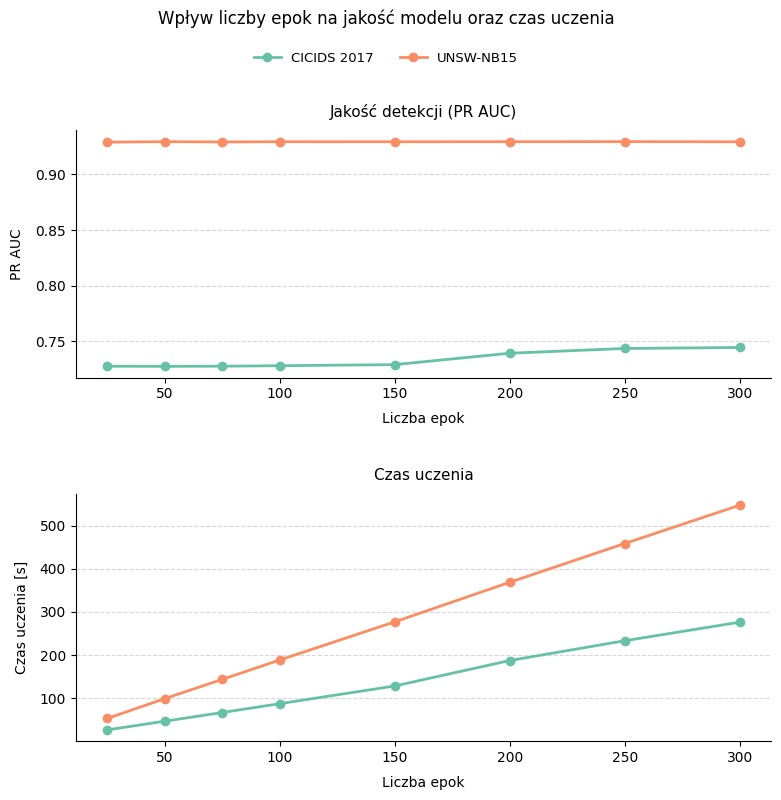

In [22]:
# ## 6a. Liczba epok -- wykres

if not epochs.empty and epoch_col in epochs:
    fig, axes = plt.subplots(2, 1, figsize=(8, 7.5))

    for ax, metric, title_str, y_label in zip(
        axes, 
        ['AUC_PR', 'runtime_train'], 
        ['Jakość detekcji (PR AUC)', 'Czas uczenia'], 
        ['PR AUC', 'Czas uczenia [s]']
    ):
        for j, ds in enumerate(DATASETS):
            q = epochs[epochs['dataset_name'].eq(ds)].groupby(epoch_col)[['AUC_PR', 'runtime_train']].mean().sort_index()
            
            if not q.empty:
                ax.plot(
                    q.index, 
                    q[metric], 
                    marker='o',
                    linestyle='-',
                    label=DATASET_LABELS[ds],
                    color=COLORS[j],
                    linewidth=2,
                    markersize=6
                )

        ax.set_title(title_str, fontsize=11, pad=10)
        ax.set_xlabel('Liczba epok', fontsize=10, labelpad=8)
        ax.set_ylabel(y_label, fontsize=10, labelpad=8)
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)
        
        ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, legend_labels, 
        loc="upper center", 
        ncol=2, 
        frameon=True, 
        facecolor="white", 
        edgecolor="none",
        bbox_to_anchor=(0.5, 1.02),
        fontsize=9.5
    )

    fig.suptitle('Wpływ liczby epok na jakość modelu oraz czas uczenia', 
                 fontsize=12, y=1.06)

    fig.tight_layout(h_pad=3.0)
    savefig(fig, "lunar_epochs_tbd")
    plt.show()

In [23]:
## 6b. Odporność - tabela zbiorcza (tab:robustness_summary_final)


def esc_text(s):
    s = str(s)
    replacements = [
        ("\\", r"\textbackslash{}"),
        ("&", r"\&"), ("%", r"\%"), ("$", r"\$"), ("#", r"\#"),
        ("_", r"\_"), ("{", r"\{"), ("}", r"\}"),
        ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}"),
    ]
    for old, new in replacements:
        s = s.replace(old, new)
    return s


DATASET_LABELS = {"CICIDS": "CICIDS 2017", "UNSW_NB15": "UNSW-NB15"}

METRIC_MAP = [
    ("AUC_PR", "PR AUC", 3),
    ("F1", "$F_1$", 3),
    ("Precision", "Precision", 3),
    ("Recall", "Recall", 3),
    ("ConfusionMatrix_FP", "FP", 0),
]


def latex_num(x, nd=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")


def pm_math(mean, std, nd=3):
    if pd.isna(mean):
        return "--"
    if pd.isna(std):
        return f"${latex_num(mean, nd)}$"
    return f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$"


def build_robustness_table_latex(summary_df, label, caption):
    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llllccccc}", r"\hline",
        "Zbiór & Fuzja & Scenariusz & Poziom & " + " & ".join(h for _, h, _ in METRIC_MAP) + r" \\",
        r"\hline",
    ]
    df_sorted = summary_df.sort_values(["dataset_name", "fusion_strategy", "Scenariusz", "Poziom"])
    prev_ds = None
    for _, row in df_sorted.iterrows():
        ds_label = DATASET_LABELS.get(row["dataset_name"], row["dataset_name"])
        if prev_ds is not None and ds_label != prev_ds:
            lines.append(r"\hline")
        cells = [esc_text(ds_label), esc_text(row["fusion_strategy"]), esc_text(row["Scenariusz"]),
                 latex_num(row["Poziom"], 2)]
        for col, _, nd in METRIC_MAP:
            cells.append(pm_math(row.get(f"{col}_mean"), row.get(f"{col}_std"), nd))
        lines.append(" & ".join(cells) + r" \\")
        prev_ds = ds_label
    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


tex = build_robustness_table_latex(
    summary, "tab:robustness_summary_final",
    "Zestawienie wyników analizy odporności dla poszczególnych scenariuszy zaburzeń.")
print(tex)

with open(FIG_DIR / "tab_robustness_summary_final.tex", "w", encoding="utf-8") as f:
    f.write(tex)
summary.to_csv(FIG_DIR / "tab_robustness_summary_final.csv", index=False)

NameError: name 'summary' is not defined

In [ ]:
# ## 6b. Odporność -- funkcja pomocnicza

def plot_robustness_scenario(label, stem, metrics):
    q = robust[robust['Scenariusz'].eq(label)]
    if q.empty:
        print(f"Brak danych dla scenariusza: {label}")
        return

    n_metrics = len(metrics)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(8, 4.5 * n_metrics), squeeze=False)
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        groups = list(q.groupby(['dataset_name', 'fusion_strategy'], dropna=False))
        
        for idx, ((ds, fusion), sub) in enumerate(groups):
            z = sub.groupby('Poziom')[metric].mean().sort_index()
            
            fusion_str = f" — {fusion}" if pd.notna(fusion) and fusion else ""
            label_name = f"{DATASET_LABELS.get(ds, ds)}{fusion_str}"
            
            ax.plot(
                z.index, 
                z.values, 
                marker='o' if idx % 2 == 0 else 's',
                linestyle='-' if idx % 2 == 0 else '--',
                label=label_name,
                color=COLORS[idx % len(COLORS)],
                linewidth=2,
                markersize=6
            )

        ax.set_title(f"Metryka: {metric}", fontsize=11, pad=10)
        ax.set_xlabel('Poziom zaburzenia', fontsize=10, labelpad=8)
        ax.set_ylabel(metric, fontsize=10, labelpad=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)
        
        ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, legend_labels, 
        loc="upper center", 
        ncol=3, 
        frameon=True, 
        facecolor="white", 
        edgecolor="none",
        bbox_to_anchor=(0.5, 0.98),
        fontsize=9
    )

    fig.suptitle(f"Odporność na zaburzenia — scenariusz: {label}", 
                 fontsize=12, y=0.99)

    fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=3.0)
    savefig(fig, stem)
    plt.show()

Zapisano: figrobustness-imbalance-final.pdf oraz figrobustness-imbalance-final.png


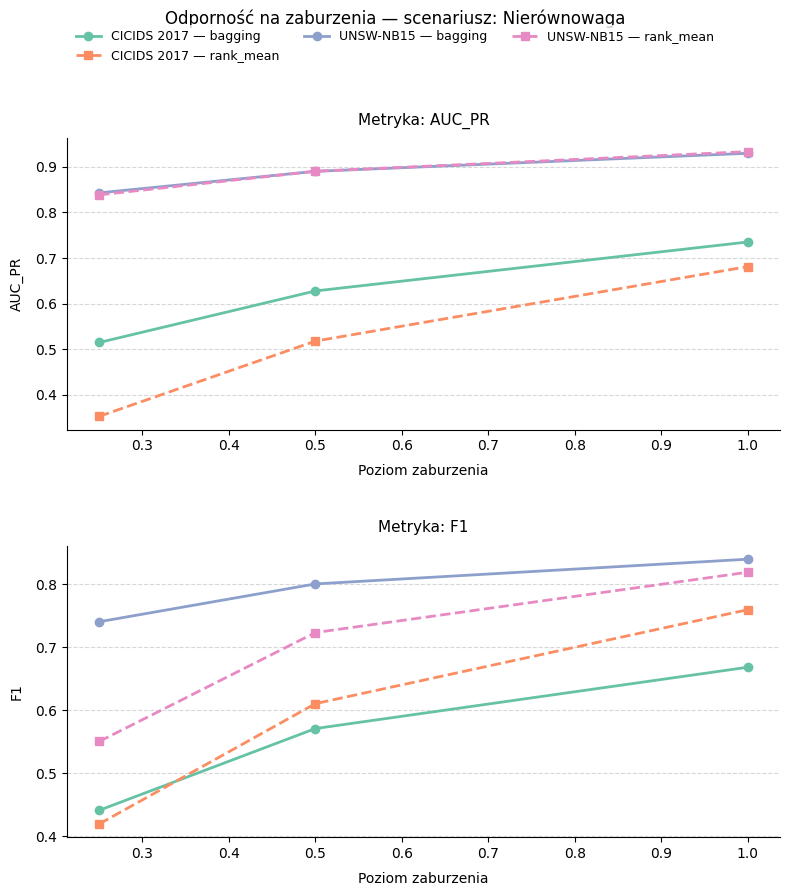

In [ ]:
## 6b. Odporność - wykres: nierównowaga klas
plot_robustness_scenario('Nierównowaga', 'figrobustness-imbalance-final', ['AUC_PR', 'F1'])

Zapisano: figrobustness-noise-final.pdf oraz figrobustness-noise-final.png


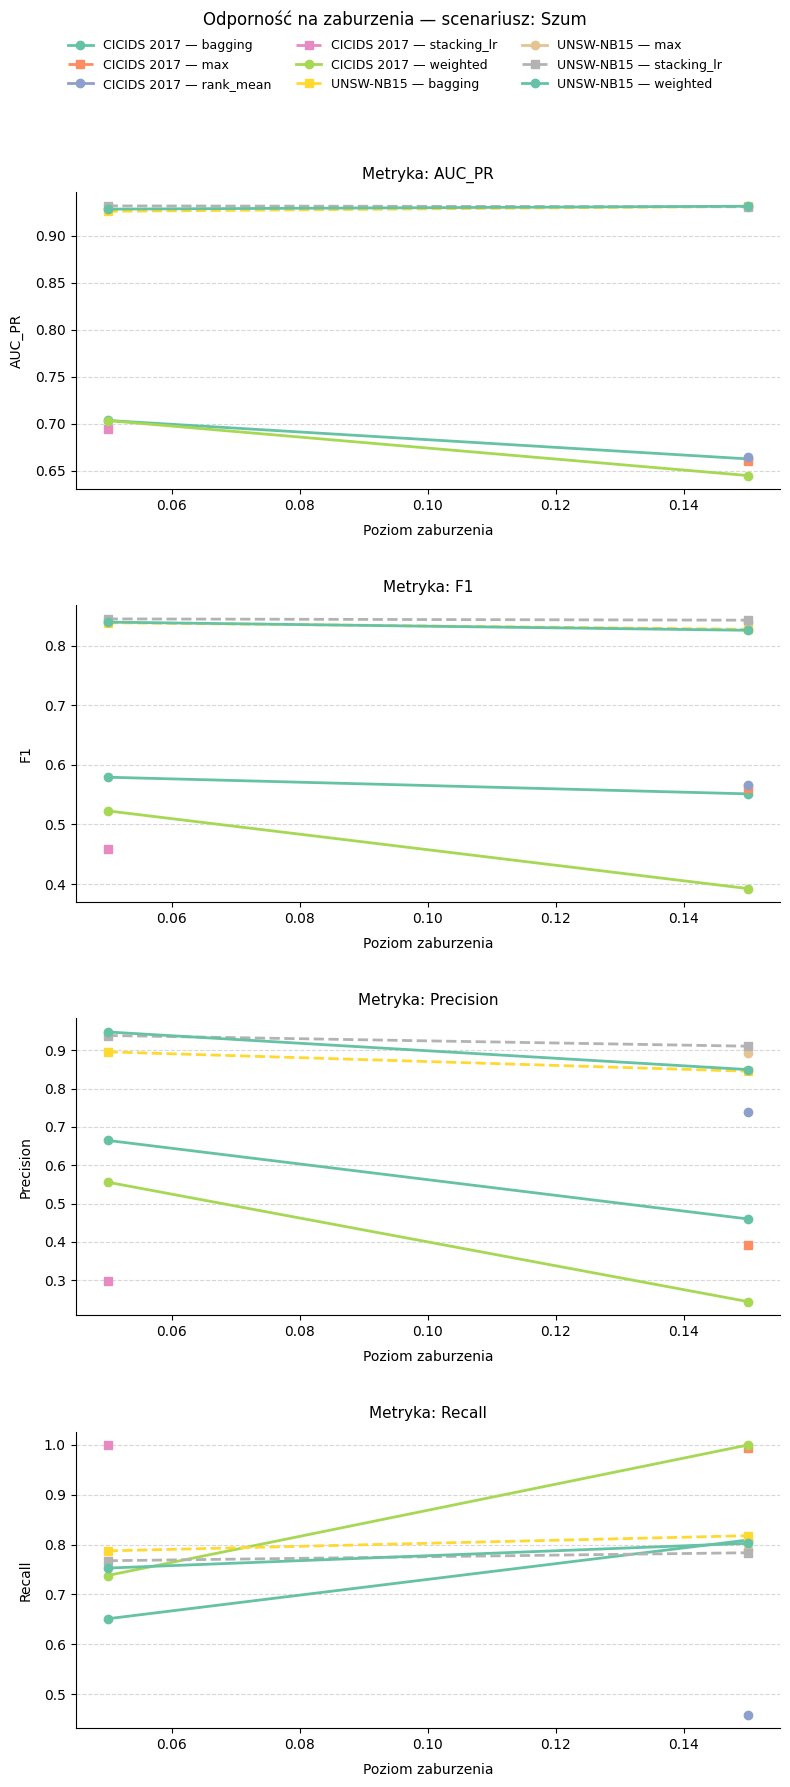

In [ ]:
## 6b. Odporność - wykres: szum cech
plot_robustness_scenario('Szum', 'figrobustness-noise-final', ['AUC_PR', 'F1', 'Precision', 'Recall'])

Zapisano: figrobustness-feature-dropout-final.pdf oraz figrobustness-feature-dropout-final.png


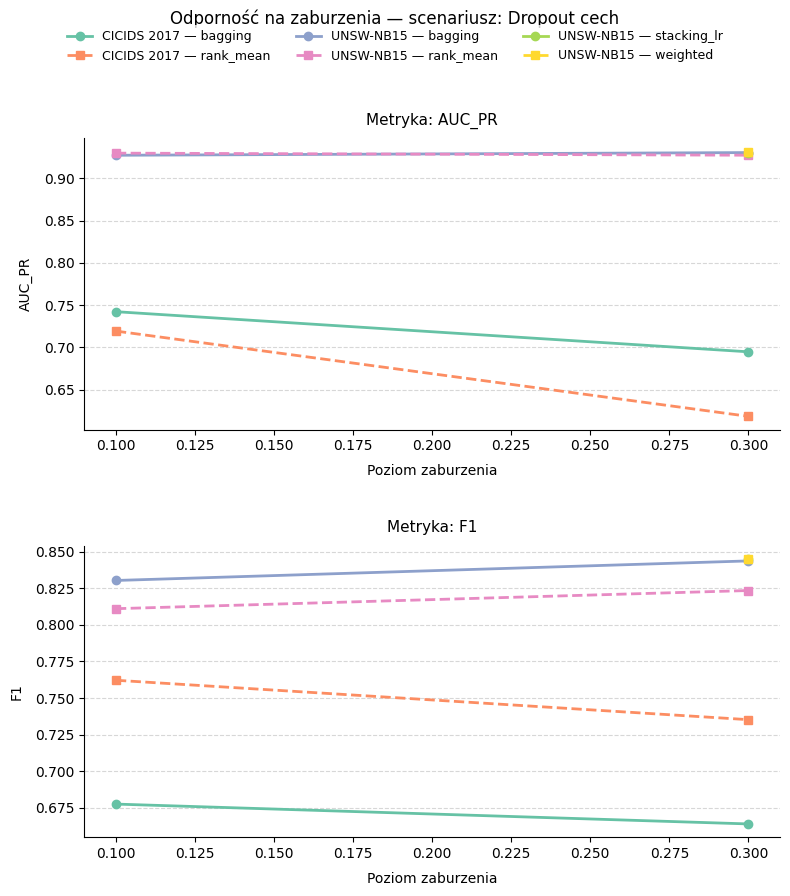

In [ ]:
## 6b. Odporność - wykres: dropout cech
plot_robustness_scenario('Dropout cech', 'figrobustness-feature-dropout-final', ['AUC_PR', 'F1'])

In [24]:
## tab:classical-ensemble-final

CLASSICAL_SPECS = [
    ("IsolationForest", None, "Isolation Forest"),
    ("LOF", None, "LOF"),
    ("OneClassSVM", None, "One-Class SVM"),
    ("Ensemble_without_LUNAR", "rank_mean", "Zespół klasyczny"),
]
METRICS = ["AUC_ROC", "AUC_PR", "Precision", "Recall", "F1"]
METRIC_HEADERS = {"AUC_ROC": "ROC AUC", "AUC_PR": "PR AUC", "Precision": "Precision",
                  "Recall": "Recall", "F1": "F1"}


def pm_math(mean, std, nd=3, bold=False):
    if pd.isna(mean):
        return "--"
    val = f"${latex_num(mean, nd)} \\pm {latex_num(std, nd)}$" if not pd.isna(std) else f"${latex_num(mean, nd)}$"
    if bold:
        val = f"${{\\mathbf{{{val[1:-1]}}}}}$"
    return val


def is_significantly_best(stats_per_model):
    """Najwyzsza wartosc jest pogrubiana TYLKO, gdy jej przedzial (mean - std) nie
    zachodzi na przedzial (mean + std) drugiej najlepszej wartosci."""
    valid = {m: v for m, v in stats_per_model.items() if not pd.isna(v[0])}
    result = {m: False for m in stats_per_model}
    if not valid:
        return result
    ranked = sorted(valid.items(), key=lambda kv: kv[1][0], reverse=True)
    best_model, (best_mean, best_std) = ranked[0]
    best_std = 0 if pd.isna(best_std) else best_std
    if len(ranked) < 2:
        result[best_model] = True
        return result
    _, (second_mean, second_std) = ranked[1]
    second_std = 0 if pd.isna(second_std) else second_std
    if (best_mean - best_std) > (second_mean + second_std):
        result[best_model] = True
    return result


def build_classical_table_latex(df_in, label, caption):
    stats = {}
    for mt, fs, lab in CLASSICAL_SPECS:
        for dset in DATASETS:
            mask = (df_in.model_type == mt) & (df_in.dataset_name == dset)
            if fs:
                mask &= (df_in.fusion_strategy == fs)
            a = agg(df_in, mask, metrics=METRICS)
            stats[(dset, lab)] = {m: (a.get(f"{m}_mean"), a.get(f"{m}_std")) for m in METRICS}

    bold_flags = {}
    for dset in DATASETS:
        for m in METRICS:
            per_model = {lab: stats[(dset, lab)][m] for _, _, lab in CLASSICAL_SPECS}
            bold_flags[(dset, m)] = is_significantly_best(per_model)

    lines = [
        r"\begin{table}[H]", r"\centering",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{llccccc}", r"\hline",
        "Zbiór & Model & " + " & ".join(METRIC_HEADERS[m] for m in METRICS) + r" \\",
        r"\hline",
    ]
    prev_ds = None
    for dset in DATASETS:
        ds_label = DATASET_LABELS[dset]
        for _, _, lab in CLASSICAL_SPECS:
            if prev_ds is not None and ds_label != prev_ds:
                lines.append(r"\hline")
            cells = [esc_text(ds_label), esc_text(lab)]
            for m in METRICS:
                mean, std = stats[(dset, lab)][m]
                is_best = bold_flags[(dset, m)].get(lab, False)
                cells.append(pm_math(mean, std, 3, is_best))
            lines.append(" & ".join(cells) + r" \\")
            prev_ds = ds_label
    lines += [r"\hline", r"\end{tabular}}", r"\end{table}", "", r"Źródło: opracowanie własne."]
    return "\n".join(lines)


tex = build_classical_table_latex(
    df_std_clean, "tab:classical-ensemble-final",
    "Porównanie zespołu klasycznego z modelami pojedynczymi przy standardowym progu decyzyjnym. "
    "Wartości podano jako średnia $\\pm$ odchylenie standardowe z trzech uruchomień.")
print(tex)

with open(FIG_DIR / "tab_classical_ensemble_final.tex", "w", encoding="utf-8") as f:
    f.write(tex)

\begin{table}[H]
\centering
\caption{Porównanie zespołu klasycznego z modelami pojedynczymi przy standardowym progu decyzyjnym. Wartości podano jako średnia $\pm$ odchylenie standardowe z trzech uruchomień.}
\label{tab:classical-ensemble-final}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llccccc}
\hline
Zbiór & Model & ROC AUC & PR AUC & Precision & Recall & F1 \\
\hline
CICIDS 2017 & Isolation Forest & $0{,}819 \pm 0{,}009$ & $0{,}608 \pm 0{,}010$ & $0{,}712 \pm 0{,}200$ & $0{,}501 \pm 0{,}168$ & $0{,}551 \pm 0{,}016$ \\
CICIDS 2017 & LOF & $0{,}848 \pm 0{,}008$ & $0{,}543 \pm 0{,}039$ & $0{,}583 \pm 0{,}005$ & $0{,}766 \pm 0{,}069$ & $0{,}662 \pm 0{,}026$ \\
CICIDS 2017 & One-Class SVM & $0{,}768 \pm 0{,}001$ & $0{,}623 \pm 0{,}000$ & $0{,}243 \pm 0{,}000$ & ${\mathbf{1{,}000 \pm 0{,}000}}$ & $0{,}391 \pm 0{,}000$ \\
CICIDS 2017 & Zespół klasyczny & ${\mathbf{0{,}882 \pm 0{,}002}}$ & ${\mathbf{0{,}730 \pm 0{,}015}}$ & $0{,}710 \pm 0{,}020$ & $0{,}736 \pm 0{,}024$ & ${\mathbf{0{,}722 